In [14]:
### 1. Numeric Types and Precision

x = 1                      # Default is Int64
y = 1.0                    # Float64
z = BigFloat("1.23456789") # Arbitrary-precision float

# Set global precision temporarily
using Printf
setprecision(100) do
    println("High-precision 1/3: ", BigFloat("1") / BigFloat("3"))
end

println()

High-precision 1/3: 0.33333333333333333333333333333346



In [16]:
### 2. Mathematical Functions and Broadcasting

# Define a simple function
f(x) = x^2 + 2x + 1

# Apply function to a vector using broadcasting (note the dot!)
println("f.(1:5): ", f.(1:5))  # equivalent to elementwise in MATLAB or NumPy

println()

f.(1:5): [4, 9, 16, 25, 36]



In [38]:
### 3. Symbolic Computation (fixed)

using Symbolics

@variables x_sym y_sym      # Avoid name conflict with numeric x
f_expr = x_sym^2 + 2x_sym + y_sym

# Symbolic expansion (optional for this case)
f_expanded = Symbolics.expand_derivatives(f_expr)
println("Expanded expression: ", f_expanded)

# Symbolic differentiation
dfdx = Symbolics.derivative(f_expr, x_sym)
println("df/dx: ", dfdx)

Expanded expression: 2x_sym + y_sym + x_sym^2
df/dx: 2 + 2x_sym


In [24]:
### 4. Functions and Multiple Dispatch

# Different methods for different types
f(x::Int) = x^2
f(x::Float64) = sqrt(x)

println("f(4) (Int): ", f(4))         # Uses Int method
println("f(4.0) (Float64): ", f(4.0)) # Uses Float64 method

println()

f(4) (Int): 16
f(4.0) (Float64): 2.0



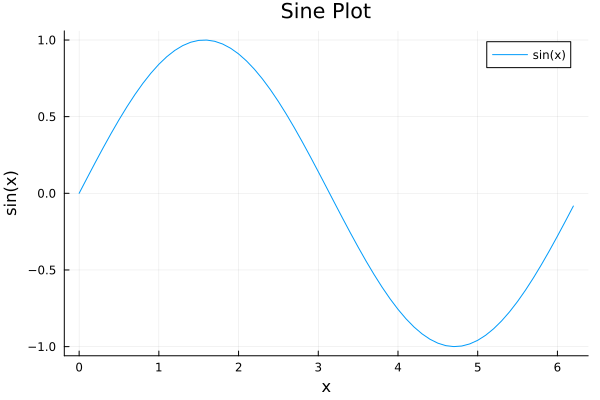

In [30]:
### 5. Plotting

using Plots

x_vals = 0:0.1:2π
y_vals = sin.(x_vals)

plot(x_vals, y_vals, label="sin(x)", title="Sine Plot", xlabel="x", ylabel="sin(x)")

In [32]:
### 6. Bit and Type Manipulation

x = 42
println("Bitstring: ", bitstring(x))     # Show bits of integer
println("Size in bytes: ", sizeof(x))    # Usually 8 bytes on 64-bit
println("Reinterpreted bits as Float64: ", reinterpret(Float64, 0x40490FDB00000000))

println()

Bitstring: 0000000000000000000000000000000000000000000000000000000000101010
Size in bytes: 8
Reinterpreted bits as Float64: 50.123870849609375



In [34]:
### 7. Multiple Return Values

function quadratic(a, b, c)
    D = b^2 - 4a*c
    return ((-b + sqrt(D)) / (2a), (-b - sqrt(D)) / (2a))
end

r1, r2 = quadratic(1, -3, 2)  # x² - 3x + 2 = 0 → roots: 1, 2
println("Roots of x² - 3x + 2: ", r1, ", ", r2)

println()

Roots of x² - 3x + 2: 2.0, 1.0



In [36]:
### 8. Introspection and Performance Tools

@time sum(1:10^7)        # Benchmarking
@code_llvm f(10)         # View LLVM IR for function call
@code_native f(10)       # View native assembly code


  0.000000 seconds
; Function Signature: f(Int64)
;  @ In[24]:4 within `f`
define i64 @julia_f_42568(i64 signext %"x::Int64") #0 {
top:
; ┌ @ intfuncs.jl:370 within `literal_pow`
; │┌ @ int.jl:88 within `*`
    %0 = mul i64 %"x::Int64", %"x::Int64"
    ret i64 %0
; └└
}
	.section	__TEXT,__text,regular,pure_instructions
	.build_version macos, 15, 0
	.globl	_julia_f_42739                  ; -- Begin function julia_f_42739
	.p2align	2
_julia_f_42739:                         ; @julia_f_42739
; Function Signature: f(Int64)
; ┌ @ In[24]:4 within `f`
; %bb.0:                                ; %top
; │ @ In[24] within `f`
	;DEBUG_VALUE: f:x <- $x0
	;DEBUG_VALUE: f:x <- $x0
; │ @ In[24]:4 within `f`
; │┌ @ intfuncs.jl:370 within `literal_pow`
; ││┌ @ int.jl:88 within `*`
	mul	x0, x0, x0
	ret
; └└└
                                        ; -- End function
.subsections_via_symbols


In [66]:
using GenericLinearAlgebra
using Random

Random.seed!(1234)

a = rand(Float16,4,4)

println(GenericLinearAlgebra.svd(a))

b = rand(Float32,4,4)

println(GenericLinearAlgebra.svd(b))

LinearAlgebra.SVD{Float16, Float16, Matrix{Float16}, Vector{Float16}}(Float16[-0.2861 -0.2279 -0.56 -0.743; -0.4375 -0.503 -0.4036 0.6265; -0.508 0.8125 -0.2517 0.1359; -0.685 -0.1858 0.678 -0.1906], Float16[2.238, 0.5254, 0.3872, 0.0839], Float16[-0.4722 -0.5815 -0.5635 -0.3484; -0.645 0.6616 -0.2935 0.2439; 0.3816 -0.147 -0.5957 0.6914; -0.4639 -0.4492 0.492 0.584])
LinearAlgebra.SVD{Float32, Float32, Matrix{Float32}, Vector{Float32}}(Float32[-0.6655654 0.473552 0.47051287 -0.33374995; -0.4325083 -0.6656533 -0.3120944 -0.52195746; -0.56161445 0.17938657 -0.5667684 0.5754853; -0.23355651 -0.54815596 0.5999905 0.53384274], Float32[1.7656738, 0.7154346, 0.4289092, 0.11972736], Float32[-0.43470368 -0.27472726 -0.5535152 -0.65511715; -0.47880298 -0.7301846 0.22950538 0.4300061; -0.5952493 0.40803576 0.6227393 -0.30229276; -0.47692627 0.47419608 -0.5031341 0.5427111])
